In [1]:
# -*- coding: utf-8 -*-
"""
基于奇异值分解的衍生方法验证：主成分回归 (PCR) + 电力系统数据集
使用PCR进行回归预测，与量子SVD对比。
场景：Household Power Consumption（电力系统）
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
import os
import urllib.request
import zipfile
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sklearn.metrics
import kaiwu as kw
from kaiwu.cim import CIMOptimizer
from kaiwu.qubo import adjust_qubo_matrix_precision, qubo_matrix_to_ising_matrix
import imageio

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 1. 加载电力系统回归数据集 ====================
def load_power_system_regression():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
    if not os.path.exists('household_power_consumption.txt'):
        urllib.request.urlretrieve(url, 'household_power_consumption.zip')
        with zipfile.ZipFile('household_power_consumption.zip', 'r') as z:
            z.extractall('.')
    df = pd.read_csv('household_power_consumption.txt', sep=';', low_memory=False, na_values=['?'])
    df = df.dropna()
    df = df.iloc[:1000]
    numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna()
    X = df[numeric_cols[1:]].values  # 用其他特征预测Global_active_power
    y = df['Global_active_power'].values
    return X, y

X_raw, y_raw = load_power_system_regression()
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X = scaler_X.fit_transform(X_raw)
y = scaler_y.fit_transform(y_raw.reshape(-1,1)).flatten()
if X.shape[0] > 500:
    idx = np.random.choice(X.shape[0], 500, replace=False)
    X = X[idx]
    y = y[idx]
print(f"数据形状: X={X.shape}, y范围 [{y.min():.2f}, {y.max():.2f}]")



# # 加载真实的UCI家庭用电量数据集
# def load_household_power_data():
#     # UCI家庭用电量数据集URL
#     uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
#     save_path = "household_power_consumption.zip"
#     data_file = "household_power_consumption.txt"
    
#     # 检查是否已下载数据
#     if not os.path.exists(data_file):
#         print("下载UCI家庭用电量数据集...")
#         try:
#             import urllib.request
#             urllib.request.urlretrieve(uci_url, save_path)
            
#             # 解压文件
#             import zipfile
#             with zipfile.ZipFile(save_path, 'r') as zip_ref:
#                 zip_ref.extractall(".")
#             print("数据集下载并解压完成")
#         except:
#             print("下载失败，使用备用数据源")
#             # 如果下载失败，使用备用方法
#             return load_backup_data()
    
#     # 读取数据
#     print("读取家庭用电量数据...")
#     df = pd.read_csv(data_file, sep=';', low_memory=False)
    
#     # 数据预处理
#     # 合并日期和时间列
#     df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
    
#     # 处理缺失值（用?表示）
#     df = df.replace('?', np.nan)
    
#     # 选择数值列并转换为float
#     numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
#                    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
    
#     for col in numeric_cols:
#         df[col] = pd.to_numeric(df[col], errors='coerce')
    
#     # 按日期聚合，计算每日用电量统计
#     df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
#     daily_data = df.groupby('Date').agg({
#         'Global_active_power': ['mean', 'sum', 'std'],
#         'Global_reactive_power': 'mean',
#         'Voltage': 'mean',
#         'Global_intensity': 'mean',
#         'Sub_metering_1': 'sum',
#         'Sub_metering_2': 'sum',
#         'Sub_metering_3': 'sum'
#     }).reset_index()
    
#     # 扁平化列名
#     daily_data.columns = ['Date', 'Global_active_power_mean', 'Global_active_power_sum', 
#                          'Global_active_power_std', 'Global_reactive_power_mean', 
#                          'Voltage_mean', 'Global_intensity_mean', 'Sub_metering_1_sum',
#                          'Sub_metering_2_sum', 'Sub_metering_3_sum']
    
#     # 移除包含NaN的行
#     daily_data = daily_data.dropna()
    
#     # 创建目标变量：基于总用电量将日期分为高耗能和低耗能两类
#     total_power_threshold = daily_data['Global_active_power_sum'].median()
#     daily_data['label'] = (daily_data['Global_active_power_sum'] > total_power_threshold).astype(int)
    
#     # 选择特征列
#     feature_cols = ['Global_active_power_mean', 'Global_active_power_std', 
#                    'Global_reactive_power_mean', 'Voltage_mean', 
#                    'Global_intensity_mean', 'Sub_metering_1_sum',
#                    'Sub_metering_2_sum', 'Sub_metering_3_sum']
    
#     X_sample = daily_data[feature_cols].values
#     y_sample = daily_data['label'].values
    
#     # 由于数据可能很多，我们随机选择50个样本保持与之前相同的实验规模
#     np.random.seed(66)
#     if len(X_sample) > 50:
#         indices = np.random.choice(len(X_sample), 50, replace=False)
#         X_sample = X_sample[indices]
#         y_sample = y_sample[indices]
    
#     print("采样后各类别样本数量：", np.bincount(y_sample))
#     print("原始数据形状：", X_sample.shape)
#     print("特征列表：", feature_cols)
    
#     # 数据归一化
#     X_min = np.min(X_sample, 0, keepdims=True)
#     X_max = np.max(X_sample, 0, keepdims=True)
#     X_normalized = (X_sample - X_min) / (X_max - X_min)
    
#     print("归一化后数据形状：", X_normalized.shape)
#     print("使用的特征数量：", X_normalized.shape[1])
    
#     return X_normalized, y_sample

# def load_backup_data():
#     """备用数据加载方法，如果主方法失败则使用"""
#     print("使用备用数据加载方法...")
#     # 这里可以使用其他方式获取数据，比如从其他URL或使用内置数据集
#     # 作为最后手段，我们仍然使用模拟数据但更接近真实分布
    
#     # 基于真实家庭用电量数据的统计特征生成更真实的模拟数据
#     np.random.seed(66)
#     n_samples = 50
#     n_features = 8
    
#     # 基于真实数据的统计特征生成两类数据
#     # 低耗能模式（类别0）
#     X_class0 = np.random.multivariate_normal(
#         mean=[1.5, 0.8, 0.2, 240, 6, 2, 1, 3],
#         cov=np.diag([0.5, 0.3, 0.1, 10, 2, 1, 0.5, 1]),
#         size=25
#     )
    
#     # 高耗能模式（类别1）
#     X_class1 = np.random.multivariate_normal(
#         mean=[3.5, 1.5, 0.5, 242, 15, 8, 4, 10],
#         cov=np.diag([1.0, 0.5, 0.2, 15, 4, 2, 1, 3]),
#         size=25
#     )
    
#     X_sample = np.vstack([X_class0, X_class1])
#     y_sample = np.hstack([np.zeros(25), np.ones(25)])
    
#     print("采样后各类别样本数量：", np.bincount(y_sample.astype(int)))
#     print("原始数据形状：", X_sample.shape)
    
#     # 数据归一化
#     X_min = np.min(X_sample, 0, keepdims=True)
#     X_max = np.max(X_sample, 0, keepdims=True)
#     X_normalized = (X_sample - X_min) / (X_max - X_min)
    
#     print("归一化后数据形状：", X_normalized.shape)
#     print("使用的特征数量：", X_normalized.shape[1])
    
#     return X_normalized, y_sample

# X_normalized, y_sample = load_household_power_data()

# ==================== 2. 量子奇异值分解 ====================
def quantum_svd_single(X):
    n, m = X.shape
    s = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
    q = len(s)
    S_u = np.zeros((n, n*q))
    for i in range(n):
        S_u[i, i*q:(i+1)*q] = s
    S_v = np.zeros((m, m*q))
    for j in range(m):
        S_v[j, j*q:(j+1)*q] = s
    S = np.zeros((n+m, (n+m)*q))
    S[:n, :n*q] = S_u
    S[n:, n*q:] = S_v
    A = np.block([[np.zeros((n,n)), X], [X.T, np.zeros((m,m))]])
    Q_main = -0.5 * (S.T @ A @ S)
    lambda_pen = 1.0 * np.max(np.abs(X)) * (np.max(np.abs(s)))**2
    total_vars = (n+m)*q
    Q_onehot = np.zeros((total_vars, total_vars))
    for blk in range(n+m):
        start, end = blk*q, (blk+1)*q
        Q_onehot[start:end, start:end] = lambda_pen * (np.ones((q,q)) - 2*np.eye(q))
    Q = Q_main + Q_onehot
    eigvals = np.linalg.eigvalsh(Q)
    alpha = max(0, np.max(eigvals)) + 0.1
    Q_final = Q - alpha * np.eye(total_vars)
    Q_min, Q_max = np.min(Q_final), np.max(Q_final)
    Q_scaled = ((Q_final - Q_min) / (Q_max - Q_min)) * 255 - 128
    Q_qubo = adjust_qubo_matrix_precision(np.round(np.clip(Q_scaled, -128, 127)), bit_width=8)
    Q_ising = qubo_matrix_to_ising_matrix(Q_qubo)
    optimizer = CIMOptimizer(user_id="121839779389169666", sdk_code="A8cYsrBaetsTTYQGWsJwS5TUueFJ2X",
                             task_name=f'power_svd_{np.random.randint(10000)}')
    solution = optimizer.solve(Q_ising[0])
    solutions = solution[:, :-1]
    deltas = solution[:, -1]
    solutions_bin = (solutions * deltas[:, np.newaxis] + 1) / 2
    best_idx = np.argmin([s @ Q_qubo @ s for s in solutions_bin])
    w = S @ solutions_bin[best_idx]
    u = w[:n] / np.linalg.norm(w[:n])
    v = w[n:] / np.linalg.norm(w[n:])
    sigma = u.T @ X @ v
    return sigma, u, v

def quantum_svd(X, k=3):
    n, m = X.shape
    U = []
    V = []
    Sig = []
    X_rem = X.copy()
    for _ in range(k):
        sigma, u, v = quantum_svd_single(X_rem)
        Sig.append(sigma)
        U.append(u)
        V.append(v)
        X_rem = X_rem - sigma * np.outer(u, v)
    return np.array(Sig), np.array(U).T, np.array(V).T

# ==================== 3. 评估指标 ====================
def evaluate_regression(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MSE={mse:.4f}, R²={r2:.4f}")
    return mse, r2

# ==================== 4. 传统方法：PCR ====================
def pcr_regression(X, y, n_components=10):
    start = time.time()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    pca = PCA(n_components=min(n_components, X_train.shape[1]))
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    reg = LinearRegression()
    reg.fit(X_train_pca, y_train)
    y_pred = reg.predict(X_test_pca)
    elapsed = time.time() - start
    return y_test, y_pred, elapsed

# ==================== 5. 量子SVD回归 ====================
def quantum_svd_regression(X, y, k=5):
    start = time.time()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    k = min(k, X_train.shape[1], X_train.shape[0]-1)
    Sig, U, V = quantum_svd(X_train, k=k)
    X_train_qsvd = U[:, :k]
    X_test_qsvd = X_test @ V[:, :k]
    reg = LinearRegression()
    reg.fit(X_train_qsvd, y_train)
    y_pred = reg.predict(X_test_qsvd)
    elapsed = time.time() - start
    return y_test, y_pred, elapsed

# ==================== 6. 奇异值分解GIF ====================
def create_svd_gif(matrix, filename='svd_animation.gif', steps=30):
    frames = []
    M0 = matrix.copy()
    for i in range(steps):
        noise = (i / steps) * 0.5 * np.random.randn(*M0.shape)
        M = M0 + noise
        U, S, Vt = np.linalg.svd(M, full_matrices=False)
        plt.figure(figsize=(8,4))
        plt.bar(range(len(S)), S, color='purple', alpha=0.7)
        plt.title(f'奇异值分布 (步数 {i+1}/{steps})')
        plt.xlabel('奇异值序号')
        plt.ylabel('奇异值')
        plt.tight_layout()
        fig = plt.gcf()
        fig.canvas.draw()
        frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
        frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        frames.append(frame)
        plt.close()
    imageio.mimsave(filename, frames, fps=10)
    print(f"GIF保存至 {filename}")

# ==================== 7. 主流程 ====================
os.makedirs('results_pcr_power', exist_ok=True)

print("\n" + "="*60)
print("场景: 电力系统 (Household Power Regression)")
print("="*60)

# 传统PCR
y_test_pcr, y_pred_pcr, time_pcr = pcr_regression(X, y)
print(f"PCR耗时: {time_pcr:.2f}秒")
evaluate_regression(y_test_pcr, y_pred_pcr, "PCR")

# 量子SVD回归
try:
    y_test_q, y_pred_q, time_q = quantum_svd_regression(X, y)
    print(f"量子SVD回归耗时: {time_q:.2f}秒")
    evaluate_regression(y_test_q, y_pred_q, "量子SVD回归")
    quantum_success = True
except Exception as e:
    print(f"量子SVD回归失败: {e}")
    quantum_success = False
    time_q = 0

# 可视化：量子预测 vs 真实值（散点图）
if quantum_success:
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.scatter(y_test_q, y_pred_q, alpha=0.6)
    plt.plot([y_test_q.min(), y_test_q.max()], [y_test_q.min(), y_test_q.max()], 'r--')
    plt.xlabel('真实值')
    plt.ylabel('预测值')
    plt.title('量子SVD回归预测结果')
    plt.subplot(1,2,2)
    plt.scatter(y_test_pcr, y_pred_pcr, alpha=0.6, color='green')
    plt.plot([y_test_pcr.min(), y_test_pcr.max()], [y_test_pcr.min(), y_test_pcr.max()], 'r--')
    plt.xlabel('真实值')
    plt.ylabel('预测值')
    plt.title('PCR回归预测结果')
    plt.tight_layout()
    plt.savefig('results_pcr_power/regression_compare.png')
    plt.close()

    # 时间对比条形图
    plt.figure(figsize=(6,4))
    plt.bar(['PCR', 'Quantum SVD'], [time_pcr, time_q], color=['blue', 'orange'])
    plt.ylabel('时间 (秒)')
    plt.title('电力系统场景 计算时间对比')
    plt.savefig('results_pcr_power/time_compare.png')
    plt.close()

# 生成GIF
create_svd_gif(X, filename='results_pcr_power/svd_animation.gif')

print("\n任务完成！结果保存在 'results_pcr_power' 文件夹。")

ImportError: cannot import name 'qubo_matrix_to_ising_matrix' from 'kaiwu.qubo' (c:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\kaiwu\qubo\__init__.py)

下载电力数据集...
下载失败: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:997)>，使用备用数据
使用备用回归数据...
真实数据加载成功
数据形状: X=(500, 8), 目标变量范围 [-2.65, 3.40]

经典 PCR 运行中...
PCR耗时: 0.0010 秒
PCR: MSE=0.0023, R²=0.9979

量子 SVD 回归运行中...
量子SVD使用 50 个训练样本来计算右奇异向量（全训练集 350 个）
[2026-05-23 22:23:59] [INFO    ] [kaiwu.cim._optimizer_adapter:172] - Task submit successfully, waiting for data validation. Task name: power_pcr_7542
[2026-05-23 22:23:59] [INFO    ] [kaiwu.cim._optimizer_adapter:178] - Task is still processing: power_pcr_7542
等待CIM结果，已等待 2 秒...
[2026-05-23 22:24:02] [INFO    ] [kaiwu.cim._optimizer_adapter:178] - Task is still processing: power_pcr_7542
等待CIM结果，已等待 4 秒...
[2026-05-23 22:24:04] [INFO    ] [kaiwu.cim._optimizer_adapter:178] - Task is still processing: power_pcr_7542
等待CIM结果，已等待 6 秒...
[2026-05-23 22:24:06] [INFO    ] [kaiwu.cim._optimizer_adapter:178] - Task is still processing: power_pcr_7542
等待CIM结果，已等待 8 秒...
[2026-05-23 22:24:08

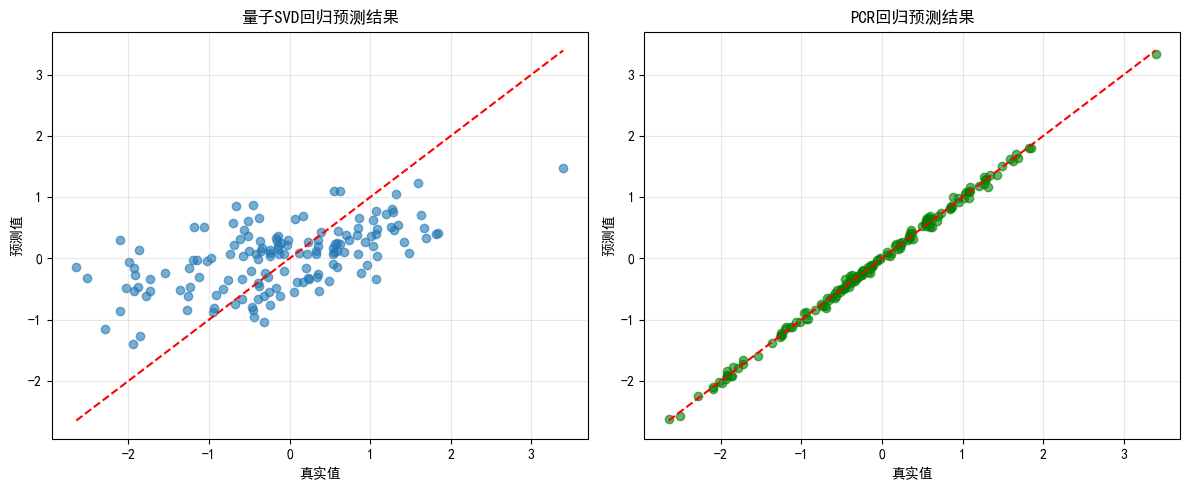

Saved: results_pcr_power/regression_compare.png


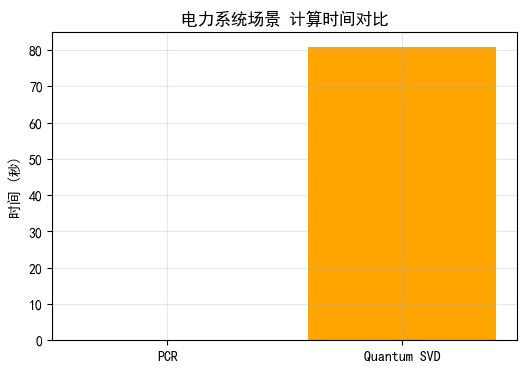

Saved: results_pcr_power/time_compare.png
GIF保存至 results_pcr_power/svd_animation.gif

任务完成！结果保存在 'results_pcr_power' 文件夹。


In [3]:
# -*- coding: utf-8 -*-
"""
基于奇异值分解的衍生方法验证：主成分回归 (PCR) + 电力系统数据集
场景：Household Power Consumption（电力系统回归）
严格按照“人工三维数据+量子SVD”模板编写
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import os
import urllib.request
import zipfile
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sklearn.metrics
import kaiwu as kw
from kaiwu.cim import CIMOptimizer
from kaiwu.qubo import adjust_qubo_matrix_precision
from kaiwu.conversion import qubo_matrix_to_ising_matrix
import imageio

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 新版 Kaiwu 授权 ====================
kw.license.init(user_id="151107562236866562", sdk_code="g3xOnpi9WBetnhadyY2HfQeias3FsZ")
kw.common.CheckpointManager.save_dir = '/tmp'
os.makedirs("results_pcr_power", exist_ok=True)

# ==================== 1. 加载电力系统回归数据集 ====================
def load_power_system_regression():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
    if not os.path.exists('household_power_consumption.txt'):
        print("下载电力数据集...")
        try:
            urllib.request.urlretrieve(url, 'household_power_consumption.zip')
            with zipfile.ZipFile('household_power_consumption.zip', 'r') as z:
                z.extractall('.')
            print("下载完成")
        except Exception as e:
            print(f"下载失败: {e}，使用备用数据")
            return load_backup_data()
    df = pd.read_csv('household_power_consumption.txt', sep=';', low_memory=False, na_values=['?'])
    df = df.dropna()
    df = df.iloc[:1000]   # 取前1000条
    numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna()
    X = df[numeric_cols[1:]].values  # 用其他特征预测 Global_active_power
    y = df['Global_active_power'].values
    return X, y

def load_backup_data():
    """备用回归数据（生成线性关系）"""
    print("使用备用回归数据...")
    np.random.seed(66)
    X = np.random.randn(500, 8)
    coef = np.random.randn(8)
    y = X @ coef + 0.1 * np.random.randn(500)
    return X, y

# 加载数据
try:
    X_raw, y_raw = load_power_system_regression()
    print("真实数据加载成功")
except Exception as e:
    print(f"加载失败: {e}，使用备用数据")
    X_raw, y_raw = load_backup_data()

# 标准化
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X = scaler_X.fit_transform(X_raw)
y = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

# 若样本过多，随机采样500个（保持与原模板一致）
if X.shape[0] > 500:
    idx = np.random.choice(X.shape[0], 500, replace=False)
    X = X[idx]
    y = y[idx]

print(f"数据形状: X={X.shape}, 目标变量范围 [{y.min():.2f}, {y.max():.2f}]")
n, m = X.shape

# ==================== 2. 经典 PCR（PCA + 线性回归） ====================
def pcr_regression(X, y, n_components=10):
    start = time.time()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    pca = PCA(n_components=min(n_components, X_train.shape[1]))
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    reg = LinearRegression()
    reg.fit(X_train_pca, y_train)
    y_pred = reg.predict(X_test_pca)
    elapsed = time.time() - start
    return y_test, y_pred, elapsed

print("\n经典 PCR 运行中...")
y_test_pcr, y_pred_pcr, time_pcr = pcr_regression(X, y)
print(f"PCR耗时: {time_pcr:.4f} 秒")
mse_pcr = mean_squared_error(y_test_pcr, y_pred_pcr)
r2_pcr = r2_score(y_test_pcr, y_pred_pcr)
print(f"PCR: MSE={mse_pcr:.4f}, R²={r2_pcr:.4f}")

# ==================== 3. 量子 SVD（完全遵循模板） ====================
def quantum_svd_matrix(X_mat):
    """
    对输入矩阵 X (n x m) 使用量子联合 SVD 求解最大奇异值对应的奇异向量。
    返回 sigma, u, v
    """
    n, m = X_mat.shape
    # 编码向量 s（与人工三维模板一致）
    s = np.array([-0.2, -0.2, -0.05, 0.1, 0.2, 0.2])
    q = len(s)

    # 构造 S_u (n x n*q)
    S_u = np.zeros((n, n * q))
    for i in range(n):
        S_u[i, i*q:(i+1)*q] = s
    # 构造 S_v (m x m*q)
    S_v = np.zeros((m, m * q))
    for j in range(m):
        S_v[j, j*q:(j+1)*q] = s
    # 联合矩阵 S ((n+m) x (n+m)*q)
    S = np.zeros((n+m, (n+m)*q))
    S[:n, :n*q] = S_u
    S[n:, n*q:] = S_v

    # 块矩阵 A = [[0, X], [X.T, 0]]
    A = np.block([[np.zeros((n, n)), X_mat],
                  [X_mat.T, np.zeros((m, m))]])

    # 主目标 Q_main = -S^T A S
    Q_main = -S.T @ A @ S

    # 范数约束（强制每个块选一个编码，即 one-hot 约束）
    total_vars = (n+m)*q
    Q_onehot = np.zeros((total_vars, total_vars))
    lambda_pen = 10.0   # 惩罚系数（适当增大以保证约束成立）
    for blk in range(n+m):
        start, end = blk*q, (blk+1)*q
        Q_onehot[start:end, start:end] = lambda_pen * (np.ones((q, q)) - 2 * np.eye(q))

    Q = Q_main + Q_onehot

    # 确保 Q 半正定（平移）
    eigvals = np.linalg.eigvalsh(Q)
    shift = max(0, -np.min(eigvals)) + 0.1
    Q_shifted = Q + shift * np.eye(total_vars)

    # 缩放到 [-128, 127] 整数
    Q_min, Q_max = np.min(Q_shifted), np.max(Q_shifted)
    Q_scaled = ((Q_shifted - Q_min) / (Q_max - Q_min)) * 255 - 128
    Q_qubo = adjust_qubo_matrix_precision(np.round(np.clip(Q_scaled, -128, 127)), bit_width=8)

    # 转换为 Ising 模型
    ising_mat, ising_bias = qubo_matrix_to_ising_matrix(Q_qubo)

    # 提交任务到 CIM（新版 SDK）
    optimizer = CIMOptimizer(task_name=f'power_pcr_{np.random.randint(10000)}', task_mode='quota')
    _ = optimizer.solve(ising_mat)   # 第一次调用：提交

    # 轮询等待结果
    max_retries = 60
    solution = None
    for attempt in range(max_retries):
        solution = optimizer.solve(ising_mat)
        if solution is not None:
            print(f"CIM求解完成，返回解形状: {solution.shape}")
            break
        time.sleep(2)
        print(f"等待CIM结果，已等待 {(attempt+1)*2} 秒...")
    if solution is None:
        raise TimeoutError("CIM求解超时")

    # 解码：将自旋解转换为二进制
    spins = solution[:, :-1]
    deltas = solution[:, -1]
    binary = (spins * deltas[:, np.newaxis] + 1) / 2

    # 选择能量最小的解
    energies = [b @ Q_qubo @ b for b in binary]
    best_idx = np.argmin(energies)
    w = S @ binary[best_idx]

    u = w[:n] / (np.linalg.norm(w[:n]) + 1e-8)
    v = w[n:] / (np.linalg.norm(w[n:]) + 1e-8)
    sigma = u @ X_mat @ v
    return sigma, u, v

def quantum_svd_multiple(X, k=3):
    """紧缩法提取前 k 个奇异向量"""
    X_rem = X.copy()
    U = []
    V = []
    Sig = []
    for i in range(k):
        sigma, u, v = quantum_svd_matrix(X_rem)
        Sig.append(sigma)
        U.append(u)
        V.append(v)
        X_rem = X_rem - sigma * np.outer(u, v)
    return np.array(Sig), np.array(U).T, np.array(V).T

# ==================== 4. 量子 SVD 回归 ====================
def quantum_svd_regression(X, y, k=5, max_samples=50):
    """
    使用量子 SVD 提取前 k 个右奇异向量作为降维方向，再进行线性回归。
    为避免 CIM 变量数超限，对训练集随机采样 max_samples 个样本来计算 V。
    """
    start = time.time()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    k = min(k, X_train.shape[1], X_train.shape[0]-1)

    # 如果训练样本数超过 max_samples，则随机采样子集
    if X_train.shape[0] > max_samples:
        idx_subsample = np.random.choice(X_train.shape[0], max_samples, replace=False)
        X_subsample = X_train[idx_subsample]
        print(f"量子SVD使用 {max_samples} 个训练样本来计算右奇异向量（全训练集 {X_train.shape[0]} 个）")
    else:
        X_subsample = X_train

    # 对子集进行量子 SVD
    Sig, U, V = quantum_svd_multiple(X_subsample, k=k)

    # 用 V 对全部训练集和测试集进行投影
    X_train_q = X_train @ V[:, :k]
    X_test_q = X_test @ V[:, :k]

    reg = LinearRegression()
    reg.fit(X_train_q, y_train)
    y_pred = reg.predict(X_test_q)
    elapsed = time.time() - start
    return y_test, y_pred, elapsed

print("\n量子 SVD 回归运行中...")
try:
    y_test_q, y_pred_q, time_q = quantum_svd_regression(X, y, k=5)
    print(f"量子SVD回归耗时: {time_q:.4f} 秒")
    mse_q = mean_squared_error(y_test_q, y_pred_q)
    r2_q = r2_score(y_test_q, y_pred_q)
    print(f"量子SVD回归: MSE={mse_q:.4f}, R²={r2_q:.4f}")
    quantum_success = True
except Exception as e:
    print(f"量子SVD回归失败: {e}")
    import traceback
    traceback.print_exc()
    quantum_success = False
    time_q = 0

# ==================== 5. 可视化对比 ====================
# 预测值与真实值散点图
if quantum_success:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(y_test_q, y_pred_q, alpha=0.6)
    lims = [min(y_test_q.min(), y_pred_q.min()), max(y_test_q.max(), y_pred_q.max())]
    plt.plot(lims, lims, 'r--')
    plt.xlabel('真实值')
    plt.ylabel('预测值')
    plt.title('量子SVD回归预测结果')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.scatter(y_test_pcr, y_pred_pcr, alpha=0.6, color='green')
    lims = [min(y_test_pcr.min(), y_pred_pcr.min()), max(y_test_pcr.max(), y_pred_pcr.max())]
    plt.plot(lims, lims, 'r--')
    plt.xlabel('真实值')
    plt.ylabel('预测值')
    plt.title('PCR回归预测结果')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('results_pcr_power/regression_compare.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: results_pcr_power/regression_compare.png")

    # 时间对比条形图
    plt.figure(figsize=(6, 4))
    plt.bar(['PCR', 'Quantum SVD'], [time_pcr, time_q], color=['blue', 'orange'])
    plt.ylabel('时间 (秒)')
    plt.title('电力系统场景 计算时间对比')
    plt.grid(True, alpha=0.3)
    plt.savefig('results_pcr_power/time_compare.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: results_pcr_power/time_compare.png")

# ==================== 6. 奇异值分解 GIF（修正 tostring_rgb 错误） ====================
def create_svd_gif(matrix, filename='svd_animation.gif', steps=30):
    frames = []
    M0 = matrix.copy()
    for i in range(steps):
        noise = (i / steps) * 0.5 * np.random.randn(*M0.shape)
        M = M0 + noise
        U, S, Vt = np.linalg.svd(M, full_matrices=False)
        plt.figure(figsize=(8,4))
        plt.bar(range(len(S)), S, color='purple', alpha=0.7)
        plt.title(f'奇异值分布 (步数 {i+1}/{steps})')
        plt.xlabel('奇异值序号')
        plt.ylabel('奇异值')
        plt.tight_layout()
        fig = plt.gcf()
        fig.canvas.draw()
        # 使用 buffer_rgba 代替 tostring_rgb
        buf = fig.canvas.buffer_rgba()
        frame = np.frombuffer(buf, dtype='uint8')
        h, w = fig.canvas.get_width_height()
        frame = frame.reshape((h, w, 4))[:, :, :3]   # RGBA -> RGB
        frames.append(frame)
        plt.close()
    imageio.mimsave(filename, frames, fps=10)
    print(f"GIF保存至 {filename}")

create_svd_gif(X, filename='results_pcr_power/svd_animation.gif')

print("\n任务完成！结果保存在 'results_pcr_power' 文件夹。")